In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from astropy import constants, units

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = ''

In [4]:
def read_uvb(rootdir, filename):
    
    # First read in the file, line by line
    with open(rootdir+filename) as file:
        uvb_lines = [line.rstrip() for line in file]
        
    # Next, isolate a grid of redshifts
    
    # Specify default delimiter
    # Necessary for processing later
    
    # HM05 and 12
    if filename in ['hm05_galaxy.ascii','hm05_quasar.ascii','hm12_galaxy.ascii']:
        dm = '  '
    # KS19 or FG20
    else:
        dm = ' '

    # Read all lines relevant to redshift
    uvb_lines_z_grid = uvb_lines[uvb_lines.index('# z_grid')+1: uvb_lines.index('# wav_grid')]
    # Split apart the strings
    uvb_lines_z_grid_split = [z_grid_str.strip().replace(dm,',').split(',') for z_grid_str in uvb_lines_z_grid]
    # Flatten the list
    uvb_lines_z_grid_flat = [item for sublist in uvb_lines_z_grid_split for item in sublist]
    # Numpy-fy and flatten
    uvb_z_grid = np.array(uvb_lines_z_grid_flat, dtype='float')
   
    # Next, get the grid of wavelengths
    
    # Read in all lines relevant to wavelength
    uvb_lines_wav_grid = uvb_lines[uvb_lines.index('# wav_grid')+1: uvb_lines.index('# f_nu_list')]
    # Split apart the strings
    uvb_lines_wav_grid_split = [wav_grid_str.strip().replace(dm, ',').split(',') for wav_grid_str in uvb_lines_wav_grid]
    # Flatten the list
    uvb_lines_wav_grid_flat = [item for sublist in uvb_lines_wav_grid_split for item in sublist]
    #print(uvb_lines_wav_grid_split)
    # Numpy-fy and flatten
    uvb_wav_grid = np.array(uvb_lines_wav_grid_flat, dtype='float').flatten()    
    
    # Read in the list of f_nu and reshape
    uvb_lines_J_nu_list = uvb_lines[uvb_lines.index('# f_nu_list')+1:]
    # Split apart the strings
    uvb_lines_J_nu_split = [J_nu_str.strip().replace(dm, ',').split(',') for J_nu_str in uvb_lines_J_nu_list]
    # Flatten and reshape
    uvb_J_nu_grid = np.array([item for sublist in uvb_lines_J_nu_split for item in sublist], dtype='float').reshape((len(uvb_z_grid), len(uvb_wav_grid))) 
    
    return uvb_z_grid, uvb_wav_grid, uvb_J_nu_grid

In [5]:
# Isolate data form HM05, HM12, FG20
hm05_z_grid, hm05_wav_grid, hm05_J_nu_grid = read_uvb(rootdir, 'hm05_galaxy.ascii')
hm05q_z_grid, hm05q_wav_grid, hm05q_J_nu_grid = read_uvb(rootdir, 'hm05_quasar.ascii')

hm12_z_grid, hm12_wav_grid, hm12_J_nu_grid = read_uvb(rootdir, 'hm12_galaxy.ascii')

ks19_q14_z_grid, ks19_q14_wav_grid, ks19_q14_J_nu_grid = read_uvb(rootdir, 'ks19_q14.ascii')
ks19_q18_z_grid, ks19_q18_wav_grid, ks19_q18_J_nu_grid = read_uvb(rootdir, 'ks19_q18.ascii')
ks19_q20_z_grid, ks19_q20_wav_grid, ks19_q20_J_nu_grid = read_uvb(rootdir, 'ks19_q20.ascii')

fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb(rootdir, 'fg20_galaxy.ascii')

In [6]:
from astropy import constants
from astropy import units

def wav_2_freq(wav):
    return 3e8/(wav*1e-10)
    
def wav_2_ryd(wav):
    # Wavelength in Angstrom, convert to m
    # Astropy has Ryd in inverse meters
    return 1/(wav*1e-10*constants.Ryd.value)

In [7]:
# Convert wavelength grids to energies
hm05_ryd_grid = wav_2_ryd(hm05_wav_grid)
hm05q_ryd_grid = wav_2_ryd(hm05q_wav_grid)

hm12_ryd_grid = wav_2_ryd(hm12_wav_grid)

ks19_q14_ryd_grid = wav_2_ryd(ks19_q14_wav_grid)
ks19_q18_ryd_grid = wav_2_ryd(ks19_q18_wav_grid)
ks19_q20_ryd_grid = wav_2_ryd(ks19_q20_wav_grid)

fg20_ryd_grid = wav_2_ryd(fg20_wav_grid)

In [8]:
# Convert wavelength grids to frequencies
hm05_freq_grid = wav_2_freq(hm05_wav_grid)
hm05q_freq_grid = wav_2_freq(hm05q_wav_grid)

hm12_freq_grid = wav_2_freq(hm12_wav_grid)

ks19_q14_freq_grid = wav_2_freq(ks19_q14_wav_grid)
ks19_q18_freq_grid = wav_2_freq(ks19_q18_wav_grid)
ks19_q20_freq_grid = wav_2_freq(ks19_q20_wav_grid)

fg20_freq_grid = wav_2_freq(fg20_wav_grid)

In [9]:
(hm12_wav_grid[np.argmin(np.abs(hm12_ryd_grid-1))],
 hm12_ryd_grid[np.argmin(np.abs(hm12_ryd_grid-1))], 
hm12_freq_grid[np.argmin(np.abs(hm12_ryd_grid-1))]/1e14)

(912.0, 0.9991963273929687, 32.89473684210526)

In [10]:
def fetch_sed(z, uvb_z_grid, uvb_J_nu_grid):
    
    # First find the redshift closest to the desired one 
    # Search the redshift grid for the same
    
    idx = np.argmin(np.abs(uvb_z_grid-z))
    
    # Isolate f_nu
    
    uvb_J_nu = uvb_J_nu_grid[idx]
    
    return uvb_J_nu

In [11]:
z_test = 1

In [12]:
hm05_J_nu_test = fetch_sed(z_test, hm05_z_grid, hm05_J_nu_grid)
hm05q_J_nu_test = fetch_sed(z_test, hm05q_z_grid, hm05q_J_nu_grid)

hm12_J_nu_test = fetch_sed(z_test, hm12_z_grid, hm12_J_nu_grid)

ks19_q14_J_nu_test = fetch_sed(z_test, ks19_q14_z_grid, ks19_q14_J_nu_grid)
ks19_q18_J_nu_test = fetch_sed(z_test, ks19_q18_z_grid, ks19_q18_J_nu_grid)
ks19_q20_J_nu_test = fetch_sed(z_test, ks19_q20_z_grid, ks19_q20_J_nu_grid)

fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

In [13]:
IP_dict = {'CIII': 24.383,
           'NIII': 29.601,
           'OIII': 35.117,
           'NIV': 47.448,
           'CIV': 47.887,
           'OIV': 54.934,
           'OV': 77.413,
           'NV': 77.472,
           'OVI': 113.9}

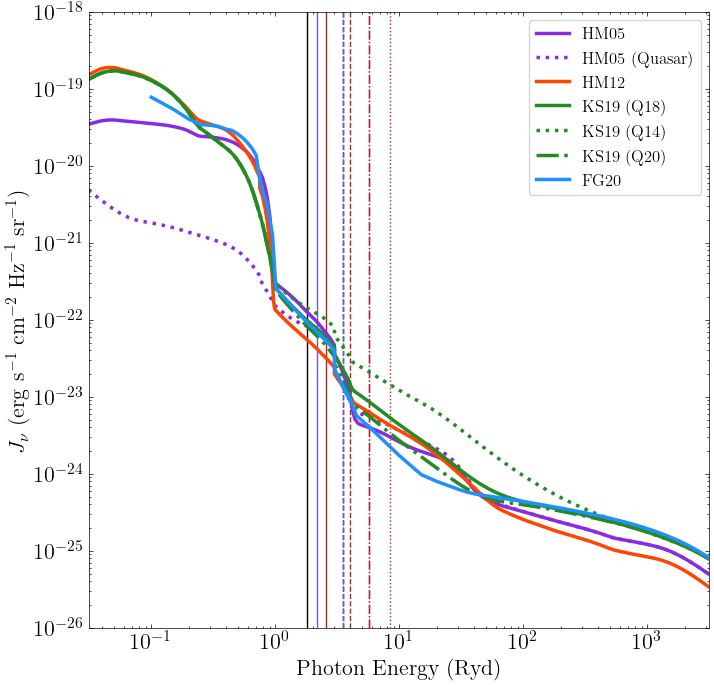

In [14]:
fig, ax = plt.subplots(1, figsize=(8,8))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-26,1e-18)
ax.set_xlim(10**-1.5, 10**3.5)

ax.axvline(IP_dict['CIII']/13.6, linestyle='-', color='black', lw=1)
ax.axvline(IP_dict['CIV']/13.6, linestyle='--', color='black', lw=1)

ax.axvline(IP_dict['NIII']/13.6, linestyle='-', color='slateblue', lw=1)
ax.axvline(IP_dict['NIV']/13.6, linestyle='--', color='slateblue', lw=1)
ax.axvline(IP_dict['NV']/13.6, linestyle='-.', color='slateblue', lw=1)

ax.axvline(IP_dict['OIII']/13.6, linestyle='-', color='firebrick', lw=1)
ax.axvline(IP_dict['OIV']/13.6, linestyle='--', color='firebrick', lw=1)
ax.axvline(IP_dict['OV']/13.6, linestyle='-.', color='firebrick', lw=1)
ax.axvline(IP_dict['OVI']/13.6, linestyle=':', color='firebrick', lw=1)


ax.plot(hm05_ryd_grid, hm05_J_nu_test, lw=2.5, label=r'HM05', color='blueviolet')
ax.plot(hm05q_ryd_grid, hm05q_J_nu_test, lw=2.5, label=r'HM05 (Quasar)', color='blueviolet', linestyle=':')

ax.plot(hm12_ryd_grid, hm12_J_nu_test, lw=2.5, label=r'HM12', color='orangered')

ax.plot(ks19_q18_ryd_grid, ks19_q18_J_nu_test, lw=2.5, label=r'KS19 (Q18)', color='forestgreen')
ax.plot(ks19_q14_ryd_grid, ks19_q14_J_nu_test, lw=2.5, label=r'KS19 (Q14)', color='forestgreen', linestyle=':')
ax.plot(ks19_q20_ryd_grid, ks19_q20_J_nu_test, lw=2.5, label=r'KS19 (Q20)', color='forestgreen', linestyle='-.')

ax.plot(fg20_ryd_grid, fg20_J_nu_test, lw=2.5, label=r'FG20', color='dodgerblue')

#ax.set_title('$z$={}'.format(z_test))
ax.set_xlabel('Photon Energy (Ryd)')
ax.set_ylabel(r'$J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Hz}^{-1} \ \mathrm{sr}^{-1})$')

#ax.axvline(1, linestyle=':')

ax.legend()

#plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/FG20_vs_HM12_UVB.png', dpi=300)

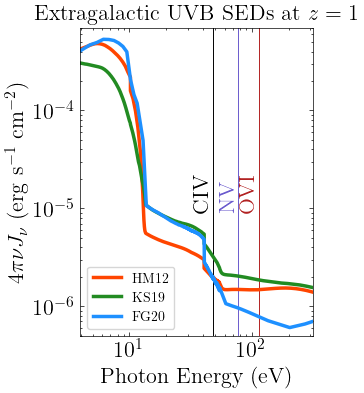

In [24]:
fig, ax = plt.subplots(1, figsize=(3,4))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(5e-7,7e-4)
ax.set_xlim(10**0.6, 10**2.5)

#ax.axvline(IP_dict['CIII'], linestyle='-', color='black', lw=.7)
ax.axvline(IP_dict['CIV'], linestyle='-', color='black', lw=.7)
ax.text(IP_dict['CIV'], 1e-5, 'CIV', rotation=90, color='black', horizontalalignment='right')

#ax.axvline(IP_dict['NIII'], linestyle='-', color='slateblue', lw=.7)
#ax.axvline(IP_dict['NIV'], linestyle='--', color='slateblue', lw=.7)
ax.axvline(IP_dict['NV'], linestyle='-', color='slateblue', lw=.7)
ax.text(IP_dict['NV'], 1e-5, 'NV', rotation=90, color='slateblue', horizontalalignment='right')

#ax.axvline(IP_dict['OIII'], linestyle='-', color='firebrick', lw=.7)
#ax.axvline(IP_dict['OIV'], linestyle='--', color='firebrick', lw=.7)
#ax.axvline(IP_dict['OV'], linestyle='-.', color='firebrick', lw=.7)
ax.axvline(IP_dict['OVI'], linestyle='-', color='firebrick', lw=.7)
ax.text(IP_dict['OVI'], 1e-5, 'OVI', rotation=90, color='firebrick', horizontalalignment='right')

#ax.plot(hm05_ryd_grid*13.61, 
#        4*np.pi*hm05_freq_grid*hm05_J_nu_test, 
#        lw=2.5, label=r'HM05', color='blueviolet')
#ax.plot(hm05q_ryd_grid*13.61, 
#        4*np.pi*hm05q_freq_grid*hm05q_J_nu_test, 
#        lw=2.5, label=r'HM05 (Quasar)', color='blueviolet', linestyle=':')

ax.plot(hm12_ryd_grid*13.61, 
        4*np.pi*hm12_freq_grid*hm12_J_nu_test, 
        lw=2.5, label=r'HM12', color='orangered')

ax.plot(ks19_q18_ryd_grid*13.61, 
        4*np.pi*ks19_q18_freq_grid*ks19_q18_J_nu_test, 
        lw=2.5, label='KS19', #label=r'KS19 (Q18)', 
        color='forestgreen')
#ax.plot(ks19_q14_ryd_grid*13.61, 
#        4*np.pi*ks19_q14_freq_grid*ks19_q14_J_nu_test, 
#        lw=2.5, label=r'KS19 (Q14)', color='forestgreen', linestyle=':')
#ax.plot(ks19_q20_ryd_grid*13.61, 
#        4*np.pi*ks19_q20_freq_grid*ks19_q20_J_nu_test, 
#        lw=2.5, label=r'KS19 (Q20)', color='forestgreen', linestyle='-.')

ax.plot(fg20_ryd_grid*13.61, 
        4*np.pi*fg20_freq_grid*fg20_J_nu_test, 
        lw=2.5, label=r'FG20', color='dodgerblue')

ax.set_title(r'Extragalactic UVB SEDs at $z=1$', fontsize=16)
ax.set_xlabel('Photon Energy (eV)')
ax.set_ylabel(r'$4 \pi \nu J_\nu \ (\mathrm{erg} \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2})$')

#ax.axvline(1, linestyle=':')

ax.legend(fontsize=10, loc='lower left')

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/FG20_vs_HM12_UVB.png', dpi=300)